In [1]:
import pandas as pd
import numpy as np
import glob
import os
import re
from sklearn.model_selection import train_test_split
# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:


dataset_path = "../../../EOI_data/**/*.csv"
all_files = glob.glob(dataset_path, recursive=True)

# Filter: exclude files dengan nama diawali "MASTER_DATA_EOI"
pattern = re.compile(r"^MASTER_DATA_EOI")

filtered_files = [
    file for file in all_files if not pattern.match(os.path.basename(file))
]

df_list = []
for file in filtered_files:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

# Gabungkan seluruh data
df_raw = pd.concat(df_list, ignore_index=True)

print(f"Total file ditemukan     : {len(all_files)}")
print(f"Total baris data awal    : {df_raw.shape[0]}")
df_raw.head()


Total file ditemukan     : 217
Total baris data awal    : 1745092


,As At Month,Visa Type,Occupation,EOI Status,Points,Count EOIs,Nominated State
0,03/2024,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,60,<20,ACT
1,03/2024,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,65,<20,ACT
2,03/2024,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,70,<20,ACT
3,03/2024,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,75,<20,ACT
4,03/2024,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,80,<20,ACT


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1745092 entries, 0 to 1745091
Data columns (total 7 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   As At Month      object
 1   Visa Type        object
 2   Occupation       object
 3   EOI Status       object
 4   Points           int64 
 5   Count EOIs       object
 6   Nominated State  object
dtypes: int64(1), object(6)
memory usage: 93.2+ MB


In [4]:
df_raw["Count EOIs"].value_counts()

Count EOIs
<20     1516813
20         8675
21         8164
22         7762
23         7242
         ...   
1200          1
1214          1
917           1
1176          1
1280          1
Name: count, Length: 1100, dtype: int64

In [4]:
df_raw["Count EOIs"] = df_raw["Count EOIs"].replace("<20", 10)


In [6]:
df_raw['Visa Type'].value_counts()

Visa Type
491SNR State or Territory Nominated - Regional    891253
190SAS Skilled Australian Sponsored               849223
189PTS Points-Tested Stream                         3660
491FSR Family Sponsored - Regional                   956
Name: count, dtype: int64

In [9]:
df_raw.isnull().sum()

As At Month        0
Visa Type          0
Occupation         0
EOI Status         0
Points             0
Count EOIs         0
Nominated State    0
dtype: int64

In [10]:
df_raw.duplicated().sum()


np.int64(0)

In [11]:


df_raw['EOI Status'].value_counts()

EOI Status
SUBMITTED    821578
CLOSED       612674
LODGED       172142
HOLD          94092
INVITED       44606
Name: count, dtype: int64

In [10]:
df_raw["Visa Type"].value_counts()


Visa Type
491SNR State or Territory Nominated - Regional    891253
190SAS Skilled Australian Sponsored               849223
189PTS Points-Tested Stream                         3660
491FSR Family Sponsored - Regional                   956
Name: count, dtype: int64

In [45]:
df_filtered = df_raw[df_raw["EOI Status"].isin(["SUBMITTED","LODGED"])]


In [46]:
df_filtered

,As At Month,Visa Type,Occupation,EOI Status,Points,Count EOIs,Nominated State
0,03/2024,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,60,10,ACT
1,03/2024,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,65,10,ACT
2,03/2024,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,70,10,ACT
3,03/2024,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,75,10,ACT
4,03/2024,190SAS Skilled Australian Sponsored,131112 Sales and Marketing Manager,SUBMITTED,80,10,ACT
...,...,...,...,...,...,...,...
1745082,02/2026,491SNR State or Territory Nominated - Regional,639211 Retail Buyer,SUBMITTED,80,10,WA
1745083,02/2026,491SNR State or Territory Nominated - Regional,639211 Retail Buyer,SUBMITTED,85,10,WA
1745084,02/2026,491SNR State or Territory Nominated - Regional,639211 Retail Buyer,SUBMITTED,90,10,WA
1745085,02/2026,491SNR State or Territory Nominated - Regional,639211 Retail Buyer,SUBMITTED,95,10,WA


In [84]:
df_filtered.to_csv('df_eoi.csv')

In [20]:
feature_cols = [col for col in df_filtered.columns if col not in ["As At Month", "EOI Status"]]

# Temukan duplikat berdasarkan fitur saja
duplicates = df_filtered[df_filtered.duplicated(subset=feature_cols, keep=False)]
print(f"Jumlah baris duplikat: {len(duplicates)}")
duplicates.sort_values(feature_cols)


Jumlah baris duplikat: 888762


,As At Month,Visa Type,Occupation,EOI Status,Points,Count EOIs,Nominated State
179875,08/2024,189PTS Points-Tested Stream,133111 Construction Project Manager,SUBMITTED,95,10,ACT
179881,08/2024,189PTS Points-Tested Stream,133111 Construction Project Manager,LODGED,95,10,ACT
179927,08/2024,189PTS Points-Tested Stream,134111 Child Care Centre Manager,SUBMITTED,85,10,ACT
179929,08/2024,189PTS Points-Tested Stream,134111 Child Care Centre Manager,LODGED,85,10,ACT
179940,08/2024,189PTS Points-Tested Stream,134213 Primary Health Organisation Manager,SUBMITTED,70,10,ACT
...,...,...,...,...,...,...,...
1384053,11/2025,491SNR State or Territory Nominated - Regional,639211 Retail Buyer,SUBMITTED,110,10,NSW
1479014,12/2025,491SNR State or Territory Nominated - Regional,639211 Retail Buyer,SUBMITTED,110,10,NSW
1575177,01/2026,491SNR State or Territory Nominated - Regional,639211 Retail Buyer,SUBMITTED,110,10,NSW
1672365,02/2026,491SNR State or Territory Nominated - Regional,639211 Retail Buyer,SUBMITTED,110,10,NSW


In [47]:
df_filtered["Count EOIs"] = df_filtered["Count EOIs"].astype(int)

C:\Users\User\AppData\Local\Temp\ipykernel_18092\3622896026.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Count EOIs"] = df_filtered["Count EOIs"].astype(int)


In [48]:
df_filtered["As At Month"] = pd.to_datetime(df_filtered["As At Month"])


C:\Users\User\AppData\Local\Temp\ipykernel_18092\532193848.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered["As At Month"] = pd.to_datetime(df_filtered["As At Month"])
C:\Users\User\AppData\Local\Temp\ipykernel_18092\532193848.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["As At Month"] = pd.to_datetime(df_filtered["As At Month"])


In [49]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 993720 entries, 0 to 1745086
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   As At Month      993720 non-null  datetime64[ns]
 1   Visa Type        993720 non-null  object        
 2   Occupation       993720 non-null  object        
 3   EOI Status       993720 non-null  object        
 4   Points           993720 non-null  int64         
 5   Count EOIs       993720 non-null  int64         
 6   Nominated State  993720 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 60.7+ MB


In [ ]:
# -------------------------------------------------------
# CELL 1: Buat Dataset Per Kombinasi (Agregasi)
# -------------------------------------------------------

GROUP_COLS = ["Occupation", "Visa Type", "Nominated State", "Points"]

# Pisahkan SUBMITTED dan LODGED
df_sub = df_filtered[df_filtered["EOI Status"] == "SUBMITTED"]
df_lod = df_filtered[df_filtered["EOI Status"] == "LODGED"]

# Agregasi SUBMITTED per kombinasi
agg_sub = (
    df_sub.groupby(GROUP_COLS)
    .agg(
        total_months_observed=("As At Month", "nunique"),
        avg_count_submitted=("Count EOIs", "mean"),
        max_count_submitted=("Count EOIs", "max"),
        min_count_submitted=("Count EOIs", "min"),
        std_count_submitted=("Count EOIs", "std"),
        trend_submitted=(
            "Count EOIs",
            lambda x: x.iloc[-1] - x.iloc[0],
        ),  # tren awal→akhir
        last_count_submitted=("Count EOIs", "last"),
        first_count_submitted=("Count EOIs", "first"),
    )
    .reset_index()
)

agg_sub["std_count_submitted"] = agg_sub["std_count_submitted"].fillna(0)
agg_sub["growth_rate"] = agg_sub["last_count_submitted"] / agg_sub[
    "first_count_submitted"
].replace(0, 1)

# Agregasi LODGED per kombinasi
agg_lod = (
    df_lod.groupby(GROUP_COLS)
    .agg(
        months_lodged=("As At Month", "nunique"),
        first_lodge_month=("As At Month", "min"),
    )
    .reset_index()
)

# Gabungkan
df_combo = agg_sub.merge(agg_lod, on=GROUP_COLS, how="left")
df_combo["months_lodged"] = df_combo["months_lodged"].fillna(0)

# Hitung bulan sejak pertama kali muncul di data
data_start = df_filtered["As At Month"].min()
df_combo["first_lodge_month"] = pd.to_datetime(df_combo["first_lodge_month"])
df_combo["months_until_lodge"] = (
    (df_combo["first_lodge_month"] - data_start).dt.days / 30
).fillna(999)  # 999 = belum pernah lodge

# Target: apakah kombinasi ini pernah LODGE minimal 1 kali?
df_combo["is_lodgeable"] = (df_combo["months_lodged"] > 0).astype(int)

# Tambahan: rasio bulan lodge vs total bulan diamati
df_combo["lodge_rate"] = df_combo["months_lodged"] / df_combo["total_months_observed"]

print(f"Total kombinasi unik: {len(df_combo)}")
print(f"\nDistribusi target (is_lodgeable):")
print(df_combo["is_lodgeable"].value_counts())
print(
    f"Rasio: {df_combo['is_lodgeable'].value_counts()[0] / df_combo['is_lodgeable'].value_counts()[1]:.1f}:1"
)
print(f"\n5 baris contoh:")
print(
    df_combo[
        GROUP_COLS + ["avg_count_submitted", "months_lodged", "is_lodgeable"]
    ].head()
)

Fitur baru berhasil dibuat:
['points_bucket', 'volatility', 'count_vs_state_avg', 'count_vs_occ_avg', 'is_small_queue', 'is_large_queue', 'growth_rate_log', 'points_x_count', 'occ_popularity']

Shape df_fe: (52976, 27)


In [66]:
# -------------------------------------------------------
# CELL 1: Feature Engineering Tambahan
# (jalankan setelah df_combo sudah ada dari xgboost_final.py)
# -------------------------------------------------------
 
df_fe = df_combo.copy()
 
# --- FITUR BARU 1: Points bucketing ---
# Points bukan linear — ada threshold tertentu yang bermakna
df_fe["points_bucket"] = pd.cut(
    df_fe["Points"],
    bins=[0, 60, 70, 80, 90, 100, 999],
    labels=[1, 2, 3, 4, 5, 6]
).astype(int)
 
# --- FITUR BARU 2: Volatilitas antrian ---
# Kombinasi dengan std tinggi = antrian fluktuatif = mungkin sedang aktif diproses
df_fe["volatility"] = df_fe["std_count_submitted"] / (df_fe["avg_count_submitted"] + 1)
 
# --- FITUR BARU 3: Ukuran antrian relatif ---
# Dibandingkan rata-rata semua kombinasi di State yang sama
state_avg = df_fe.groupby("Nominated State")["avg_count_submitted"].transform("mean")
df_fe["count_vs_state_avg"] = df_fe["avg_count_submitted"] / (state_avg + 1)
 
# --- FITUR BARU 4: Ukuran antrian relatif vs Occupation yang sama ---
occ_avg = df_fe.groupby("Occupation")["avg_count_submitted"].transform("mean")
df_fe["count_vs_occ_avg"] = df_fe["avg_count_submitted"] / (occ_avg + 1)
 
# --- FITUR BARU 5: Apakah antrian sangat kecil? ---
# Dari diagnostik: LODGED hampir selalu count_lodged=10 (<20)
# Kombinasi dengan antrian submitted sangat kecil mungkin tidak kompetitif
df_fe["is_small_queue"] = (df_fe["avg_count_submitted"] < 20).astype(int)
df_fe["is_large_queue"] = (df_fe["avg_count_submitted"] > 100).astype(int)
 
# --- FITUR BARU 6: Tren relatif (growth rate yang disederhanakan) ---
df_fe["growth_rate_log"] = np.log1p(df_fe["growth_rate"])
 
# --- FITUR BARU 7: Interaksi Points × avg_count ---
# Poin tinggi + antrian besar = sangat kompetitif
df_fe["points_x_count"] = df_fe["Points"] * np.log1p(df_fe["avg_count_submitted"])
 
# --- FITUR BARU 8: Jumlah kombinasi serupa per Occupation ---
# Occupation yang banyak kombinasi State-nya = lebih populer
occ_combo_count = df_fe.groupby("Occupation")["Nominated State"].transform("count")
df_fe["occ_popularity"] = occ_combo_count
 
print("Fitur baru berhasil dibuat:")
new_features = ["points_bucket", "volatility", "count_vs_state_avg", "count_vs_occ_avg",
                "is_small_queue", "is_large_queue", "growth_rate_log",
                "points_x_count", "occ_popularity"]
print(new_features)
print(f"\nShape df_fe: {df_fe.shape}")

Fitur baru berhasil dibuat:
['points_bucket', 'volatility', 'count_vs_state_avg', 'count_vs_occ_avg', 'is_small_queue', 'is_large_queue', 'growth_rate_log', 'points_x_count', 'occ_popularity']

Shape df_fe: (52976, 27)


In [ ]:

# -------------------------------------------------------
# CELL 1: Agregasi + Feature Engineering FINAL
# -------------------------------------------------------
 
GROUP_COLS = ["Occupation", "Visa Type", "Nominated State", "Points"]
 
# Pastikan urutan waktu benar
df_filtered = df_filtered.sort_values(
    GROUP_COLS + ["As At Month"]
).reset_index(drop=True)
 
# Pisahkan SUBMITTED dan LODGED
df_sub = df_filtered[df_filtered["EOI Status"] == "SUBMITTED"]
df_lod = df_filtered[df_filtered["EOI Status"] == "LODGED"]
 
# Agregasi SUBMITTED
agg_sub = df_sub.groupby(GROUP_COLS).agg(
    total_months_observed = ("As At Month", "nunique"),
    avg_count_submitted   = ("Count EOIs", "mean"),
    max_count_submitted   = ("Count EOIs", "max"),
    min_count_submitted   = ("Count EOIs", "min"),
    std_count_submitted   = ("Count EOIs", "std"),
    trend_submitted       = ("Count EOIs", lambda x: x.iloc[-1] - x.iloc[0]),
    last_count_submitted  = ("Count EOIs", "last"),
    first_count_submitted = ("Count EOIs", "first"),
).reset_index()
 
agg_sub["std_count_submitted"] = agg_sub["std_count_submitted"].fillna(0)
agg_sub["growth_rate"] = (
    agg_sub["last_count_submitted"] / agg_sub["first_count_submitted"].replace(0, 1)
)
 
# Agregasi LODGED
agg_lod = df_lod.groupby(GROUP_COLS).agg(
    months_lodged     = ("As At Month", "nunique"),
    first_lodge_month = ("As At Month", "min"),
).reset_index()
 
# Gabungkan
df_combo = agg_sub.merge(agg_lod, on=GROUP_COLS, how="left")
df_combo["months_lodged"]    = df_combo["months_lodged"].fillna(0)
df_combo["first_lodge_month"] = pd.to_datetime(df_combo["first_lodge_month"])
df_combo["months_until_lodge"] = (
    (df_combo["first_lodge_month"] - df_filtered["As At Month"].min()).dt.days / 30
).fillna(999)
df_combo["is_lodgeable"] = (df_combo["months_lodged"] > 0).astype(int)
df_combo["lodge_rate"]   = df_combo["months_lodged"] / df_combo["total_months_observed"]
 
# Feature Engineering
df_fe = df_combo.copy()
 
df_fe["points_bucket"]      = pd.cut(df_fe["Points"], bins=[0,60,70,80,90,100,999], labels=[1,2,3,4,5,6]).astype(int)
df_fe["volatility"]         = df_fe["std_count_submitted"] / (df_fe["avg_count_submitted"] + 1)
df_fe["growth_rate_log"]    = np.log1p(df_fe["growth_rate"])
df_fe["points_x_count"]     = df_fe["Points"] * np.log1p(df_fe["avg_count_submitted"])
df_fe["is_small_queue"]     = (df_fe["avg_count_submitted"] < 20).astype(int)
df_fe["is_large_queue"]     = (df_fe["avg_count_submitted"] > 100).astype(int)
df_fe["count_vs_state_avg"] = df_fe["avg_count_submitted"] / (df_fe.groupby("Nominated State")["avg_count_submitted"].transform("mean") + 1)
df_fe["count_vs_occ_avg"]   = df_fe["avg_count_submitted"] / (df_fe.groupby("Occupation")["avg_count_submitted"].transform("mean") + 1)
df_fe["occ_popularity"]     = df_fe.groupby("Occupation")["Nominated State"].transform("count")
 
print(f"Total kombinasi unik : {len(df_fe)}")
print(f"Distribusi target    :\n{df_fe['is_lodgeable'].value_counts()}")
print(f"Rasio imbalance      : {df_fe['is_lodgeable'].value_counts()[0] / df_fe['is_lodgeable'].value_counts()[1]:.1f}:1")
 




In [67]:
# -------------------------------------------------------
# CELL 2: Encoding & Prepare Features (versi baru)
# -------------------------------------------------------
 
df_model2 = df_fe.copy()
 
le_occ2 = LabelEncoder()
df_model2["occupation_enc"] = le_occ2.fit_transform(df_model2["Occupation"])
 
df_model2 = pd.get_dummies(df_model2, columns=["Visa Type", "Nominated State"], dtype=int)
 
drop_cols = ["Occupation", "first_lodge_month", "months_lodged",
             "lodge_rate", "months_until_lodge", "is_lodgeable"]
 
feature_cols2 = [c for c in df_model2.columns if c not in drop_cols]
 
X2 = df_model2[feature_cols2]
y2 = df_model2["is_lodgeable"]
 
print(f"\nJumlah fitur sebelum : {X2.shape[1] - len(new_features)}")
print(f"Jumlah fitur sekarang: {X2.shape[1]}")
 
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)


Jumlah fitur sebelum : 23
Jumlah fitur sekarang: 32


In [68]:
# -------------------------------------------------------
# CELL 3: Model dengan Parameter Lebih Kuat
# (underfitting → boleh naikkan kompleksitas model)
# -------------------------------------------------------

scale_pos_weight = (y_train2 == 0).sum() / (y_train2 == 1).sum()

model_v2 = xgb.XGBClassifier(
    n_estimators=500,  # lebih banyak trees (sebelumnya 300)
    max_depth=6,  # lebih dalam (sebelumnya 4)
    learning_rate=0.03,  # lebih lambat tapi lebih presisi
    subsample=0.85,
    colsample_bytree=0.8,
    min_child_weight=3,  # kurangi overfitting pada node kecil
    gamma=0.1,  # minimum gain untuk split
    scale_pos_weight=scale_pos_weight,
    reg_alpha=0.05,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

model_v2.fit(X_train2, y_train2)

y_pred2 = model_v2.predict(X_test2)
y_pred_proba2 = model_v2.predict_proba(X_test2)[:, 1]

print("=== HASIL SEBELUM THRESHOLD TUNING ===")
print(
    classification_report(
        y_test2, y_pred2, target_names=["Tidak Lodgeable", "Lodgeable"]
    )
)
print(f"AUC-ROC: {roc_auc_score(y_test2, y_pred_proba2):.3f}")

train_f1_v2 = f1_score(y_train2, model_v2.predict(X_train2))
test_f1_v2 = f1_score(y_test2, y_pred2)
print(f"\nTrain F1: {train_f1_v2:.3f}")
print(f"Test  F1: {test_f1_v2:.3f}")
print(f"Gap     : {train_f1_v2 - test_f1_v2:.3f}")


=== HASIL SEBELUM THRESHOLD TUNING ===
                 precision    recall  f1-score   support

Tidak Lodgeable       0.90      0.81      0.85      7423
      Lodgeable       0.64      0.79      0.71      3173

       accuracy                           0.81     10596
      macro avg       0.77      0.80      0.78     10596
   weighted avg       0.82      0.81      0.81     10596

AUC-ROC: 0.889

Train F1: 0.742
Test  F1: 0.709
Gap     : 0.033



=== THRESHOLD TUNING ===
Threshold default (0.50) → F1 Lodgeable: 0.709
Threshold optimal (0.52) → F1 Lodgeable: 0.710

Perbandingan threshold:
 Threshold |   F1 Lodge |  Precision |     Recall
------------------------------------------------
      0.30 |      0.648 |      0.497 |      0.931
      0.35 |      0.668 |      0.530 |      0.902
      0.40 |      0.685 |      0.565 |      0.870
      0.45 |      0.699 |      0.603 |      0.832
      0.50 |      0.709 |      0.642 |      0.791
      0.52 |      0.710 |      0.659 |      0.770 ← optimal


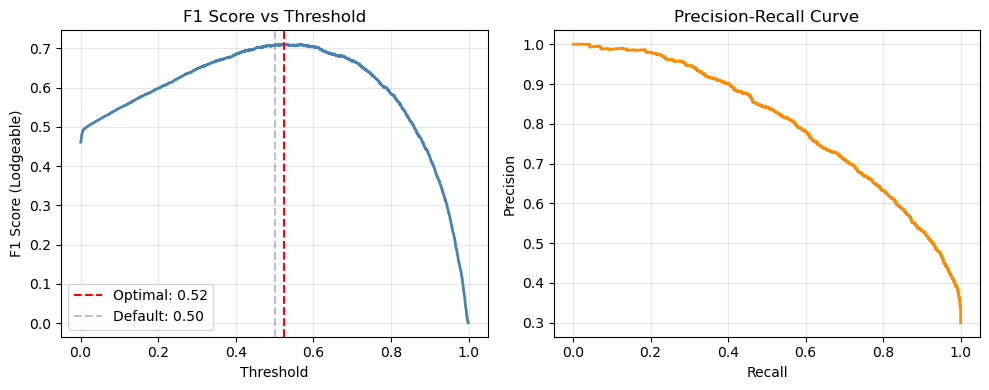

In [70]:
from sklearn.metrics import precision_recall_curve


# -------------------------------------------------------
# CELL 4: Threshold Tuning
# Cari threshold optimal yang memaksimalkan F1 Lodgeable
# -------------------------------------------------------

precisions, recalls, thresholds = precision_recall_curve(y_test2, y_pred_proba2)

# Hitung F1 untuk setiap threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Cari threshold dengan F1 tertinggi
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"\n=== THRESHOLD TUNING ===")
print(
    f"Threshold default (0.50) → F1 Lodgeable: {f1_score(y_test2, (y_pred_proba2 >= 0.50).astype(int)):.3f}"
)
print(f"Threshold optimal ({best_threshold:.2f}) → F1 Lodgeable: {best_f1:.3f}")

# Tampilkan beberapa threshold untuk perbandingan
print(f"\nPerbandingan threshold:")
print(f"{'Threshold':>10} | {'F1 Lodge':>10} | {'Precision':>10} | {'Recall':>10}")
print("-" * 48)
for thresh in [0.30, 0.35, 0.40, 0.45, 0.50, best_threshold]:
    y_tmp = (y_pred_proba2 >= thresh).astype(int)
    f1 = f1_score(y_test2, y_tmp, zero_division=0)
    prec = (y_tmp[y_test2 == 1] == 1).mean() if y_tmp.sum() > 0 else 0
    rec = (y_tmp[y_test2 == 1] == 1).mean()
    from sklearn.metrics import precision_score, recall_score

    p = precision_score(y_test2, y_tmp, zero_division=0)
    r = recall_score(y_test2, y_tmp, zero_division=0)
    marker = " ← optimal" if abs(thresh - best_threshold) < 0.01 else ""
    print(f"{thresh:>10.2f} | {f1:>10.3f} | {p:>10.3f} | {r:>10.3f}{marker}")

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_scores[:-1], color="steelblue", linewidth=2)
plt.axvline(
    x=best_threshold,
    color="red",
    linestyle="--",
    label=f"Optimal: {best_threshold:.2f}",
)
plt.axvline(x=0.50, color="gray", linestyle="--", alpha=0.5, label="Default: 0.50")
plt.xlabel("Threshold")
plt.ylabel("F1 Score (Lodgeable)")
plt.title("F1 Score vs Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(recalls[:-1], precisions[:-1], color="darkorange", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()


In [72]:
# -------------------------------------------------------
# CELL 5: Hasil Final dengan Threshold Optimal
# -------------------------------------------------------

y_pred_optimal = (y_pred_proba2 >= best_threshold).astype(int)

print(f"\n=== HASIL FINAL (Threshold = {best_threshold:.2f}) ===")
print(
    classification_report(
        y_pred_optimal, y_test2, target_names=["Tidak Lodgeable", "Lodgeable"]
    )
)

# Ringkasan perbandingan
print("\n=== RINGKASAN PENINGKATAN ===")
print(f"{'Metrik':<25} {'Sebelum':>10} {'Sesudah':>10} {'Delta':>10}")
print("-" * 55)

metrics_before = {
    "F1 Lodgeable": 0.669,
    "AUC-ROC": 0.860,
}
f1_after = f1_score(y_test2, y_pred_optimal)
auc_after = roc_auc_score(y_test2, y_pred_proba2)

print(
    f"{'F1 Lodgeable':<25} {0.669:>10.3f} {f1_after:>10.3f} {f1_after - 0.669:>+10.3f}"
)
print(f"{'AUC-ROC':<25} {0.860:>10.3f} {auc_after:>10.3f} {auc_after - 0.860:>+10.3f}")


=== HASIL FINAL (Threshold = 0.52) ===
                 precision    recall  f1-score   support

Tidak Lodgeable       0.83      0.89      0.86      6891
      Lodgeable       0.77      0.66      0.71      3705

       accuracy                           0.81     10596
      macro avg       0.80      0.78      0.79     10596
   weighted avg       0.81      0.81      0.81     10596


=== RINGKASAN PENINGKATAN ===
Metrik                       Sebelum    Sesudah      Delta
-------------------------------------------------------
F1 Lodgeable                   0.669      0.710     +0.041
AUC-ROC                        0.860      0.889     +0.029


In [ ]:
# -------------------------------------------------------
# CELL 6: Feature Importance (versi baru)
# -------------------------------------------------------

feat_imp2 = pd.Series(
    model_v2.feature_importances_, index=X_train2.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feat_imp2.head(15).plot(kind="bar", color="steelblue", alpha=0.85)
plt.title("Top 15 Fitur Paling Berpengaruh (Model v2)", fontsize=13)
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("feature_importance_v2.png", dpi=150, bbox_inches="tight")
plt.show()

# Cek apakah fitur baru masuk top 15
print("\nFitur baru yang masuk top 15:")
top15 = feat_imp2.head(15).index.tolist()
for f in new_features:
    if f in top15:
        rank = top15.index(f) + 1
        print(f"  ✅ {f} (rank #{rank})")
    else:
        print(f"  ➖ {f} (tidak masuk top 15)")


In [75]:
# -------------------------------------------------------
# CELL 7: Update Fungsi Prediksi 1 Row
# -------------------------------------------------------


def predict_lodgeable_v2(
    occupation,
    visa_type,
    points,
    state,
    avg_count_submitted=50,
    max_count_submitted=100,
    min_count_submitted=10,
    std_count_submitted=20,
    trend_submitted=0,
    last_count_submitted=50,
    first_count_submitted=50,
    total_months_observed=12,
    growth_rate=1.0,
    threshold=None,  # None = pakai threshold optimal otomatis
):
    if threshold is None:
        threshold = best_threshold

    if occupation in le_occ2.classes_:
        occ_enc = le_occ2.transform([occupation])[0]
    else:
        print(f"⚠️  Occupation '{occupation}' tidak dikenal.")
        occ_enc = int(len(le_occ2.classes_) / 2)

    # Hitung fitur turunan
    volatility = std_count_submitted / (avg_count_submitted + 1)
    growth_rate_log = np.log1p(growth_rate)
    points_x_count = points * np.log1p(avg_count_submitted)
    is_small_queue = int(avg_count_submitted < 20)
    is_large_queue = int(avg_count_submitted > 100)
    points_bucket = int(
        pd.cut([points], bins=[0, 60, 70, 80, 90, 100, 999], labels=[1, 2, 3, 4, 5, 6])[
            0
        ]
    )

    # Untuk fitur relatif (count_vs_state_avg, count_vs_occ_avg, occ_popularity)
    # pakai nilai rata-rata dari training data sebagai fallback
    count_vs_state_avg = avg_count_submitted / (
        df_fe.groupby("Nominated State")["avg_count_submitted"]
        .mean()
        .get(state, avg_count_submitted)
        + 1
    )
    count_vs_occ_avg = avg_count_submitted / (
        df_fe.groupby("Occupation")["avg_count_submitted"]
        .mean()
        .get(occupation, avg_count_submitted)
        + 1
    )
    occ_popularity = (
        df_fe.groupby("Occupation")["Nominated State"].count().get(occupation, 5)
    )

    row = {
        "Points": points,
        "total_months_observed": total_months_observed,
        "avg_count_submitted": avg_count_submitted,
        "max_count_submitted": max_count_submitted,
        "min_count_submitted": min_count_submitted,
        "std_count_submitted": std_count_submitted,
        "trend_submitted": trend_submitted,
        "last_count_submitted": last_count_submitted,
        "first_count_submitted": first_count_submitted,
        "growth_rate": growth_rate,
        "occupation_enc": occ_enc,
        "points_bucket": points_bucket,
        "volatility": volatility,
        "count_vs_state_avg": count_vs_state_avg,
        "count_vs_occ_avg": count_vs_occ_avg,
        "is_small_queue": is_small_queue,
        "is_large_queue": is_large_queue,
        "growth_rate_log": growth_rate_log,
        "points_x_count": points_x_count,
        "occ_popularity": occ_popularity,
    }

    for col in [c for c in X_train2.columns if c.startswith("Visa Type_")]:
        row[col] = 1 if col == f"Visa Type_{visa_type}" else 0
    for col in [c for c in X_train2.columns if c.startswith("Nominated State_")]:
        row[col] = 1 if col == f"Nominated State_{state}" else 0

    input_df = pd.DataFrame([row])[X_train2.columns]
    proba = model_v2.predict_proba(input_df)[0][1]
    label = "✅ LODGEABLE" if proba >= threshold else "❌ TIDAK LODGEABLE"

    print(f"\n{'=' * 52}")
    print(f"  Occupation : {occupation}")
    print(f"  Visa Type  : {visa_type}")
    print(f"  State      : {state} | Points: {points}")
    print(f"{'=' * 52}")
    print(f"  Probabilitas LODGEABLE : {proba * 100:.1f}%")
    print(f"  Threshold dipakai      : {threshold:.2f}")
    print(f"  Prediksi               : {label}")
    print(f"{'=' * 52}\n")
    return proba


In [76]:
# -------------------------------------------------------
# CELL 8: Contoh Prediksi dengan Model v2
# -------------------------------------------------------

predict_lodgeable_v2(
    occupation="233211 Civil Engineer",
    visa_type="491SNR State or Territory Nominated - Regional",
    points=80,
    state="QLD",
    avg_count_submitted=150,
    max_count_submitted=220,
    std_count_submitted=45,
    trend_submitted=50,
    growth_rate=2.5,
)

predict_lodgeable_v2(
    occupation="121318 Pig Farmer",
    visa_type="491SNR State or Territory Nominated - Regional",
    points=75,
    state="NSW",
    avg_count_submitted=10,
    max_count_submitted=15,
    std_count_submitted=3,
    trend_submitted=2,
    growth_rate=1.1,
)



  Occupation : 233211 Civil Engineer
  Visa Type  : 491SNR State or Territory Nominated - Regional
  State      : QLD | Points: 80
  Probabilitas LODGEABLE : 95.9%
  Threshold dipakai      : 0.52
  Prediksi               : ✅ LODGEABLE


  Occupation : 121318 Pig Farmer
  Visa Type  : 491SNR State or Territory Nominated - Regional
  State      : NSW | Points: 75
  Probabilitas LODGEABLE : 12.4%
  Threshold dipakai      : 0.52
  Prediksi               : ❌ TIDAK LODGEABLE



np.float32(0.12448373)